# Step 1 : Thu thập dữ liệu
Đọc bộ Customer Shopping Trends từ Kaggle.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
df=pd.read_csv(Path('data/raw/shopping_trends.csv'))
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


# Step 2 : Thống kê và trực quan hóa dữ liệu

In [2]:
df.info()
df.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14  Discount Applied   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,NaN,NaN,NaN,1950.5,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,NaN,NaN,NaN,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0
Gender,3900,2,Male,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Purchased,3900,25,Blouse,171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,3900,4,Clothing,1737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase Amount (USD),3900.0,NaN,NaN,NaN,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
Location,3900,50,Montana,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,3900,4,M,1755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,3900,25,Olive,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,3900,4,Spring,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN


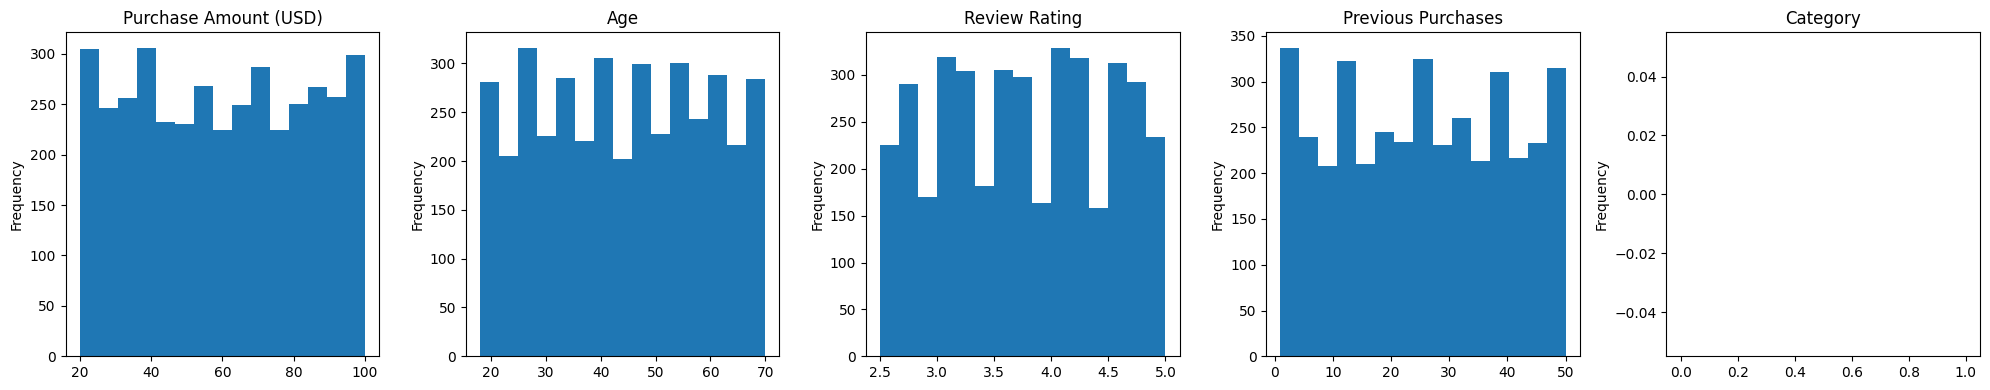

In [3]:
fig,axes=plt.subplots(1,5,figsize=(20,4))
for ax,col in zip(axes,['Purchase Amount (USD)','Age','Review Rating','Previous Purchases','Category']):
    if df[col].dtype == 'object':
        df.groupby(col)['Purchase Amount (USD)'].mean().plot.bar(ax=ax)
    else:
        pd.to_numeric(df[col],errors='coerce').plot.hist(ax=ax,bins=15)
    ax.set_title(col)
plt.tight_layout()

# Kết luận
Dữ liệu không có mốc thời gian; mỗi dòng là một giao dịch.

# Step 3 : Tiền xử lí dữ liệu

## Fill các giá trị Missing

In [4]:
df=df.copy()
for c in df.select_dtypes(include='object'): df[c]=df[c].fillna('__MISSING__')
for c in df.select_dtypes(exclude='object'): df[c]=df[c].fillna(df[c].median())

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27284\3871399976.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object'): df[c]=df[c].fillna('__MISSING__')


## Feature engineering

In [5]:
frequency_map={'Weekly':52,'Fortnightly':26,'Bi-Weekly':26,'Monthly':12,'Every 3 Months':4,'Quarterly':4,'Annually':1}
df['annual_purchase_frequency']=df['Frequency of Purchases'].map(frequency_map).fillna(0)
df['product_sales_amount_usd']=df['Purchase Amount (USD)']

## Tiền xử lí dữ liệu
Tách ngẫu nhiên 70/15/15 với seed 42 và fit encoder/scaler trên train.

# Step 4 : Train model

In [6]:
from src.pipeline import prepare_data
prepared=prepare_data('data/raw')
prepared['X_train'].shape

(2730, 158)

# Step 5 : Đánh giá

In [7]:
from src.metrics import regression_metrics
print('Tính MAE, MSE, RMSE và R² trên tập kiểm tra.')

Tính MAE, MSE, RMSE và R² trên tập kiểm tra.
